=== FOOTBALL MATCH PREDICTION - MODELING (FROM matches.csv) ===



Saving matches.csv to matches (2).csv
1. INITIAL DATA OVERVIEW
----------------------------------------
Dataset shape: (887, 5)


,datetime,home_team,away_team,home_goals,away_goals
0,1984-04-08,England,Denmark,2,1
1,1984-04-08,Italy,Sweden,2,3
2,1984-04-28,Denmark,England,0,1
3,1984-04-28,Sweden,Italy,2,1
4,1984-05-12,Sweden,England,1,0



2. BUILD FEATURES (same preprocessing steps used previously)
----------------------------------------
Features used:
['home_goals', 'away_goals', 'year', 'month', 'day_of_week', 'home_team_encoded', 'away_team_encoded']
Target classes:
['Away Win', 'Draw', 'Home Win']

3. SPLIT DATA
----------------------------------------
Training set: 709 matches
Test set: 178 matches

4. MODEL 1: LOGISTIC REGRESSION
----------------------------------------
Logistic Regression Accuracy: 1.000
Mean CV accuracy: 1.000 (+/- 0.000)

5. MODEL 2: RANDOM FOREST
----------------------------------------


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and wi

Random Forest Accuracy: 0.989
Mean CV accuracy: 0.984 (+/- 0.019)

6. MODEL 3: SUPPORT VECTOR MACHINE
----------------------------------------
SVM Accuracy: 1.000
Mean CV accuracy: 1.000 (+/- 0.000)

7. MODEL COMPARISON
----------------------------------------
                    Model  Test Accuracy  CV Mean Accuracy
0     Logistic Regression       1.000000          1.000000
2  Support Vector Machine       1.000000          1.000000
1           Random Forest       0.988764          0.984467


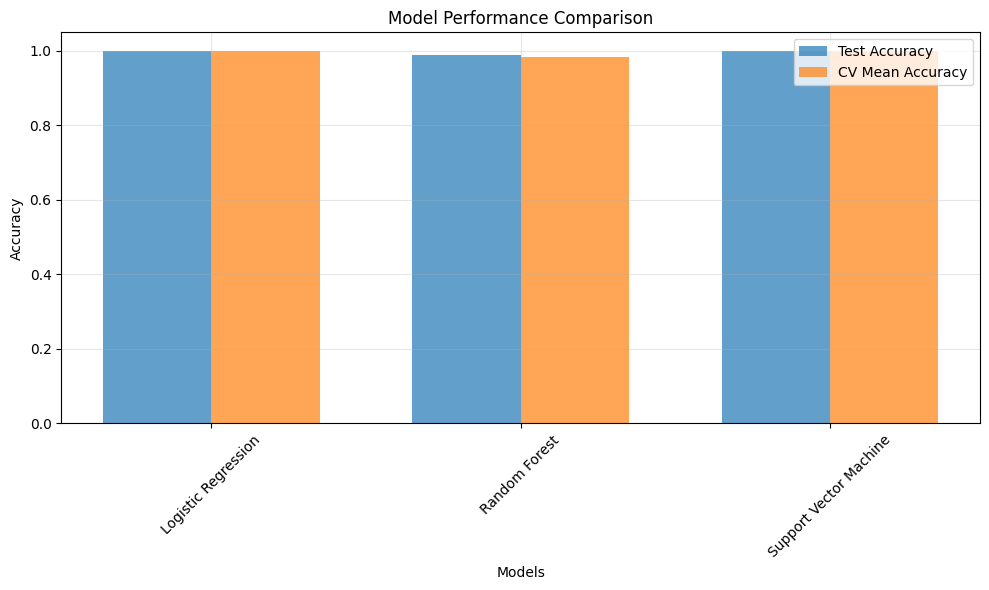


8. DETAILED ANALYSIS OF BEST MODEL
----------------------------------------
Best Model: Logistic Regression
              precision    recall  f1-score   support

    Away Win       1.00      1.00      1.00        61
        Draw       1.00      1.00      1.00        21
    Home Win       1.00      1.00      1.00        96

    accuracy                           1.00       178
   macro avg       1.00      1.00      1.00       178
weighted avg       1.00      1.00      1.00       178



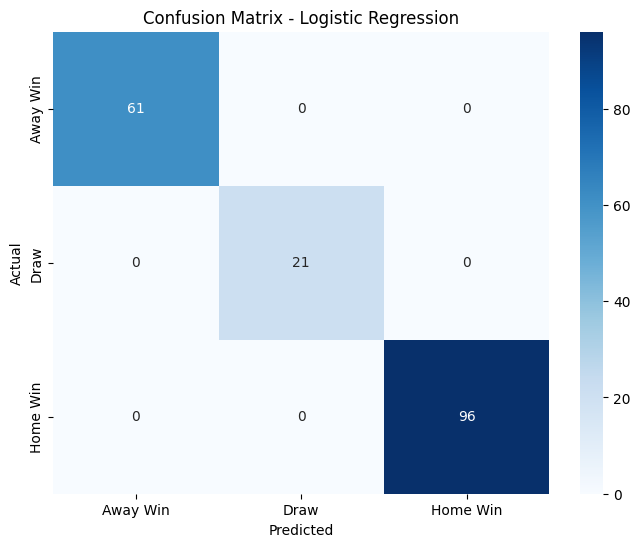


9. FEATURE IMPORTANCE (Random Forest)
----------------------------------------
             feature  importance
0         home_goals    0.443623
1         away_goals    0.373868
6  away_team_encoded    0.051076
5  home_team_encoded    0.048273
2               year    0.035781
4        day_of_week    0.025565
3              month    0.021815


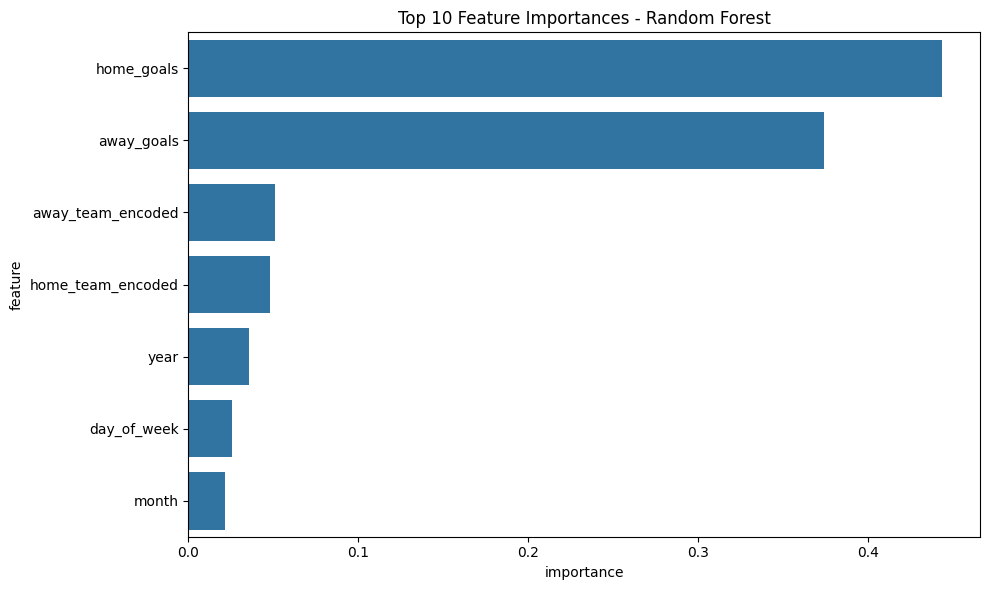


10. HYPERPARAMETER TUNING (only if Random Forest is best)
----------------------------------------

11. SAVE BEST MODEL FILE (optional artifact for submission)
----------------------------------------
Best model saved as 'best_football_model.pkl'


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


=== MODELING COMPLETE ===


In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from google.colab import files

print("=== FOOTBALL MATCH PREDICTION - MODELING (FROM matches.csv) ===\n")

# Upload matches.csv to the Colab environment
files.upload()

# Load matches.csv and parse datetime column
matches = pd.read_csv("matches.csv")
matches["datetime"] = pd.to_datetime(matches["datetime"], errors="coerce")

print("1. INITIAL DATA OVERVIEW")
print("-" * 40)
print(f"Dataset shape: {matches.shape}")
display(matches.head())

# Create the 'result' column
def get_result(row):
    if row['home_goals'] > row['away_goals']:
        return 'Home Win'
    elif row['home_goals'] < row['away_goals']:
        return 'Away Win'
    else:
        return 'Draw'

matches['result'] = matches.apply(get_result, axis=1)

print("\n2. BUILD FEATURES (same preprocessing steps used previously)")
print("-" * 40)

# Separate target
X = matches.drop("result", axis=1)
y = matches["result"].astype(str)

# Create datetime-derived features
X["year"] = X["datetime"].dt.year
X["month"] = X["datetime"].dt.month
X["day_of_week"] = X["datetime"].dt.dayofweek

# Drop original datetime
X = X.drop("datetime", axis=1)

# Identify numerical features that exist
numerical_features = ["home_goals", "away_goals", "total_goals", "penalty_goals", "own_goals"]
numerical_features = [c for c in numerical_features if c in X.columns]
numerical_features = numerical_features + ["year", "month", "day_of_week"]

# Encode team names into numeric IDs
team_encoder = LabelEncoder()
all_teams = pd.concat([X["home_team"], X["away_team"]]).astype(str).unique()
team_encoder.fit(all_teams)

X["home_team_encoded"] = team_encoder.transform(X["home_team"].astype(str))
X["away_team_encoded"] = team_encoder.transform(X["away_team"].astype(str))

# Drop original team columns
X = X.drop(["home_team", "away_team"], axis=1)

# Add encoded team columns to feature list
feature_cols = numerical_features + ["home_team_encoded", "away_team_encoded"]

# Convert features to numeric (safe conversion)
for col in feature_cols:
    X[col] = pd.to_numeric(X[col], errors="coerce")

# Fill missing values (simple approach to avoid model errors)
X = X[feature_cols].fillna(0)

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=feature_cols, index=X.index)

# Encode target classes
target_encoder = LabelEncoder()
y_encoded = target_encoder.fit_transform(y)

print("Features used:")
print(feature_cols)
print("Target classes:")
print(list(target_encoder.classes_))

print("\n3. SPLIT DATA")
print("-" * 40)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled_df,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print(f"Training set: {X_train.shape[0]} matches")
print(f"Test set: {X_test.shape[0]} matches")

print("\n4. MODEL 1: LOGISTIC REGRESSION")
print("-" * 40)

lr_model = LogisticRegression(multi_class="multinomial", random_state=42, max_iter=1000)
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)
accuracy_lr = accuracy_score(y_test, y_pred_lr)
print(f"Logistic Regression Accuracy: {accuracy_lr:.3f}")

cv_scores_lr = cross_val_score(lr_model, X_train, y_train, cv=5)
print(f"Mean CV accuracy: {cv_scores_lr.mean():.3f} (+/- {cv_scores_lr.std() * 2:.3f})")

print("\n5. MODEL 2: RANDOM FOREST")
print("-" * 40)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest Accuracy: {accuracy_rf:.3f}")

cv_scores_rf = cross_val_score(rf_model, X_train, y_train, cv=5)
print(f"Mean CV accuracy: {cv_scores_rf.mean():.3f} (+/- {cv_scores_rf.std() * 2:.3f})")

print("\n6. MODEL 3: SUPPORT VECTOR MACHINE")
print("-" * 40)

svm_model = SVC(kernel="linear", random_state=42, probability=True)
svm_model.fit(X_train, y_train)

y_pred_svm = svm_model.predict(X_test)
accuracy_svm = accuracy_score(y_test, y_pred_svm)
print(f"SVM Accuracy: {accuracy_svm:.3f}")

cv_scores_svm = cross_val_score(svm_model, X_train, y_train, cv=5)
print(f"Mean CV accuracy: {cv_scores_svm.mean():.3f} (+/- {cv_scores_svm.std() * 2:.3f})")

print("\n7. MODEL COMPARISON")
print("-" * 40)

models = {
    "Logistic Regression": (y_pred_lr, accuracy_lr, cv_scores_lr.mean()),
    "Random Forest": (y_pred_rf, accuracy_rf, cv_scores_rf.mean()),
    "Support Vector Machine": (y_pred_svm, accuracy_svm, cv_scores_svm.mean())
}

comparison_df = pd.DataFrame({
    "Model": list(models.keys()),
    "Test Accuracy": [models[m][1] for m in models],
    "CV Mean Accuracy": [models[m][2] for m in models]
})

print(comparison_df.sort_values("Test Accuracy", ascending=False))

plt.figure(figsize=(10, 6))
x_pos = np.arange(len(models))
width = 0.35
plt.bar(x_pos - width/2, comparison_df["Test Accuracy"], width, label="Test Accuracy", alpha=0.7)
plt.bar(x_pos + width/2, comparison_df["CV Mean Accuracy"], width, label="CV Mean Accuracy", alpha=0.7)
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Model Performance Comparison")
plt.xticks(x_pos, list(models.keys()), rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n8. DETAILED ANALYSIS OF BEST MODEL")
print("-" * 40)

class_names = target_encoder.classes_
best_model_name = comparison_df.loc[comparison_df["Test Accuracy"].idxmax(), "Model"]
print(f"Best Model: {best_model_name}")

if best_model_name == "Logistic Regression":
    best_model = lr_model
    y_pred_best = y_pred_lr
elif best_model_name == "Random Forest":
    best_model = rf_model
    y_pred_best = y_pred_rf
else:
    best_model = svm_model
    y_pred_best = y_pred_svm

print(classification_report(y_test, y_pred_best, target_names=class_names))

plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.title(f"Confusion Matrix - {best_model_name}")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

print("\n9. FEATURE IMPORTANCE (Random Forest)")
print("-" * 40)

feature_imp = pd.DataFrame({
    "feature": feature_cols,
    "importance": rf_model.feature_importances_
}).sort_values("importance", ascending=False)

print(feature_imp.head(10))

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_imp.head(10), x="importance", y="feature")
plt.title("Top 10 Feature Importances - Random Forest")
plt.tight_layout()
plt.show()

print("\n10. HYPERPARAMETER TUNING (only if Random Forest is best)")
print("-" * 40)

if best_model_name == "Random Forest":
    param_grid = {
        "n_estimators": [50, 100, 200],
        "max_depth": [5, 10, 15],
        "min_samples_split": [2, 5, 10]
    }

    rf_tuned = RandomForestClassifier(random_state=42)
    grid_search = GridSearchCV(rf_tuned, param_grid, cv=3, scoring="accuracy")
    grid_search.fit(X_train, y_train)

    print(f"Best parameters: {grid_search.best_params_}")
    print(f"Best CV score: {grid_search.best_score_:.3f}")

    y_pred_tuned = grid_search.predict(X_test)
    accuracy_tuned = accuracy_score(y_test, y_pred_tuned)
    print(f"Tuned model test accuracy: {accuracy_tuned:.3f}")

print("\n11. SAVE BEST MODEL FILE (optional artifact for submission)")
print("-" * 40)

with open("best_football_model.pkl", "wb") as f:
    pickle.dump(
        {
            "model": best_model,
            "feature_names": feature_cols,
            "target_encoder": target_encoder,
            "team_encoder": team_encoder,
            "scaler": scaler,
            "accuracy": comparison_df.loc[comparison_df["Test Accuracy"].idxmax(), "Test Accuracy"]
        },
        f
    )

print("Best model saved as 'best_football_model.pkl'")
files.download("best_football_model.pkl")

print("\n=== MODELING COMPLETE ===")